### Read SNOWPACK Output at PPSA WY2023-WY2025

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [5]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [6]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/ppsa'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [7]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [8]:
ds_snowpack_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_met_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2023-WY2025_base.smet")
# ds_snowpack_met_hrrrak_lapserate, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2023-WY2025_base.smet") 
ds_snowpack_met_hrrrak_lapserate, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025

/tmp/ipykernel_3887768/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_3887768/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_3887768/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_3887768/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [9]:
# cut the ds_snowpack_hrrrak to WY2023-WY2025 to match the met forcing snowpack run
# ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(timestamp=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_snowpack_hrrrak_lapserate = ds_snowpack_hrrrak_lapserate.sel(timestamp=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

### Open Observations

In [10]:
# # open observations
file = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs = xr.open_dataset(file)

# ds_obs = ds_obs.sel(time=slice("2019-10-01", "2022-09-30"))
ds_obs = ds_obs.sel(time=slice("2022-09-01", "2025-09-30"))
# ds_obs


In [11]:
# ds_snowpack_hrrrak
# ds_snowpack_hrrrak_lapserate
# ds_snowpack_met_hrrrak
# ds_obs

In [12]:
# df created in repo/juneau_field_data/1_create_snowpit_dataframe_WY2025.ipynb
# df.to_csv('/hdd/snow_hydrology/field_data/snow_pit_swe_measurements_WY2025.csv')
df_field_measurements = pd.read_csv('/hdd/snow_hydrology/field_data/snow_pit_swe_measurements_WY2025.csv', index_col=0, parse_dates=True)
df_field_measurements.head()

,snow_depth_cm,snow_depth_in,average_density,swe_mm,swe_m,swe_in
2025-01-23,126,49.606299,334,420.80,0.42080,16.566929
2025-01-28,123,48.425197,317,389.84,0.38984,15.348031
2025-02-12,133,52.362205,334,444.00,0.44400,17.480315
2025-02-16,130,51.181102,334,434.00,0.43400,17.086614
2025-02-20,128,50.393701,306,391.68,0.39168,15.420472


In [13]:
ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(timestamp=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_snowpack_hrrrak_lapserate = ds_snowpack_hrrrak_lapserate.sel(timestamp=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_snowpack_met_hrrrak = ds_snowpack_met_hrrrak.sel(timestamp=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_snowpack_met_hrrrak_lapserate = ds_snowpack_met_hrrrak_lapserate.sel(timestamp=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_obs = ds_obs.sel(time=slice("2024-09-01", "2025-07-30"))

In [14]:
ds_obs['hs'] = ds_obs['hs'].where(~((ds_obs['time'] >= np.datetime64("2024-08-20T00:00")) & (ds_obs['time'] <= np.datetime64("2024-10-15T23:59")))) # the spike in 2025

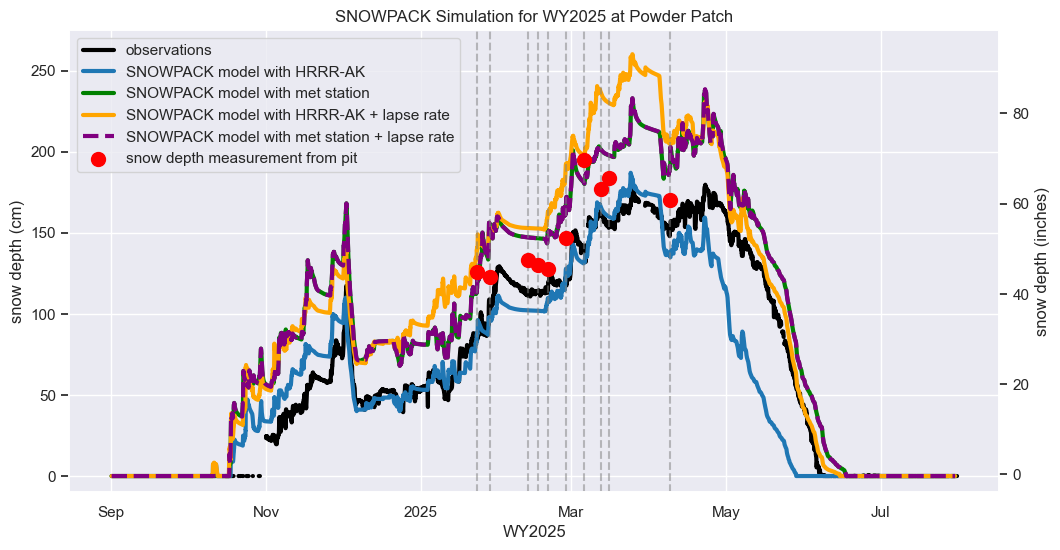

In [15]:
ds_obs.hs.plot(label = 'observations', linewidth = 3, color='black')
ds_snowpack_hrrrak.HS_mod.plot(label = 'SNOWPACK model with HRRR-AK', linewidth = 3, color='tab:blue')
ds_snowpack_met_hrrrak.HS_mod.plot(label = 'SNOWPACK model with met station ', linewidth = 3, color='green')
ds_snowpack_hrrrak_lapserate.HS_mod.plot(label = 'SNOWPACK model with HRRR-AK + lapse rate', linewidth = 3, color='orange')
ds_snowpack_met_hrrrak_lapserate.HS_mod.plot(label = 'SNOWPACK model with met station + lapse rate', linewidth = 3, color='purple', linestyle='--')

# Add vertical lines for the dates in df_field_measurements
for date in df_field_measurements.index:
    plt.axvline(x=date, color='grey', linestyle='--', alpha=0.5)
    
    # add a large dot for the snow depth at that date 
    plt.scatter(date, df_field_measurements.loc[date, 'snow_depth_cm'], color='red', s=100, zorder=5, label='snow depth measurement from pit' if date == df_field_measurements.index[0] else "")

plt.title('SNOWPACK Simulation for WY2025 at Powder Patch')
plt.xlabel('WY2025')
plt.legend()

plt.ylim([-10, 275])

plt.ylabel('snow depth (cm)')

#loc legend upper left
plt.legend(loc='upper left')

# add a second y-axis for inches
ax2 = plt.gca().twinx()
ax2.set_ylabel('snow depth (inches)')
ax2.set_ylim([-10/2.54, 250/2.54])

# turn off the second grid 
ax2.grid(False)

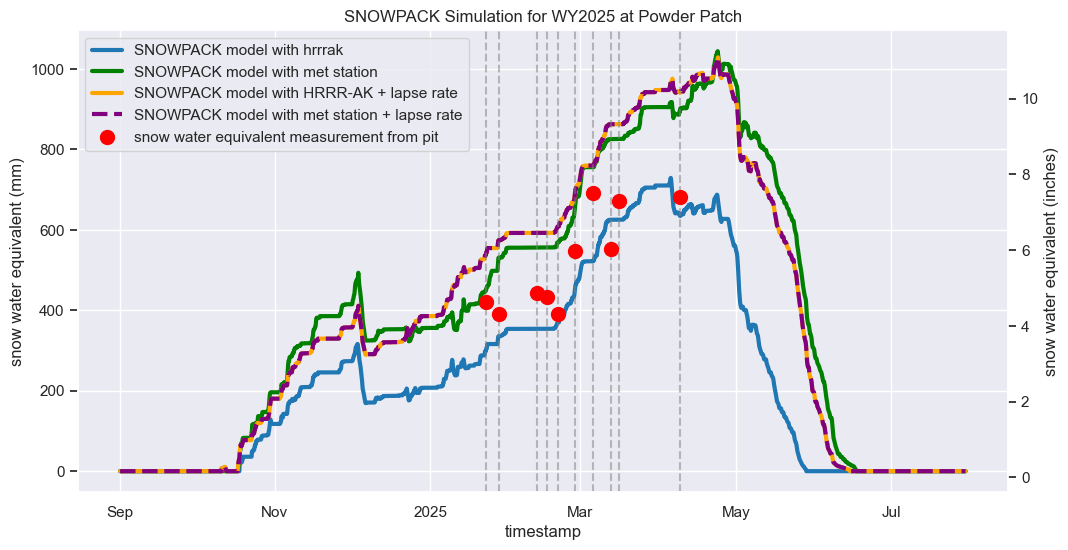

In [16]:
# SWE
ds_snowpack_hrrrak.SWE.plot(label = 'SNOWPACK model with hrrrak', linewidth = 3, color='tab:blue')
ds_snowpack_met_hrrrak.SWE.plot(label = 'SNOWPACK model with met station ', linewidth = 3, color='green')
ds_snowpack_hrrrak_lapserate.SWE.plot(label = 'SNOWPACK model with HRRR-AK + lapse rate', linewidth = 3, color='orange')
ds_snowpack_hrrrak_lapserate.SWE.plot(label = 'SNOWPACK model with met station + lapse rate', linewidth = 3, color='purple', linestyle='--')

# plot the manual swe measurements from df_field_measurements
# add verticle lines for the dates in df_field_measurements
for date in df_field_measurements.index:
    plt.axvline(x=date, color='grey', linestyle='--', alpha=0.5)
    
    # add a large dot for the snow depth at that date
plt.scatter(df_field_measurements.index, df_field_measurements['swe_mm'], color='red', s=100, zorder=5, label='snow water equivalent measurement from pit')

plt.title('SNOWPACK Simulation for WY2025 at Powder Patch')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow water equivalent (mm)')

# add a second y-axis for inches
ax2 = plt.gca().twinx()
ax2.set_ylabel('snow water equivalent (inches)')
ax2.set_ylim([-10*0.0393701, 300*0.0393701])

# remove second grid
ax2.grid(False)

plt.show()

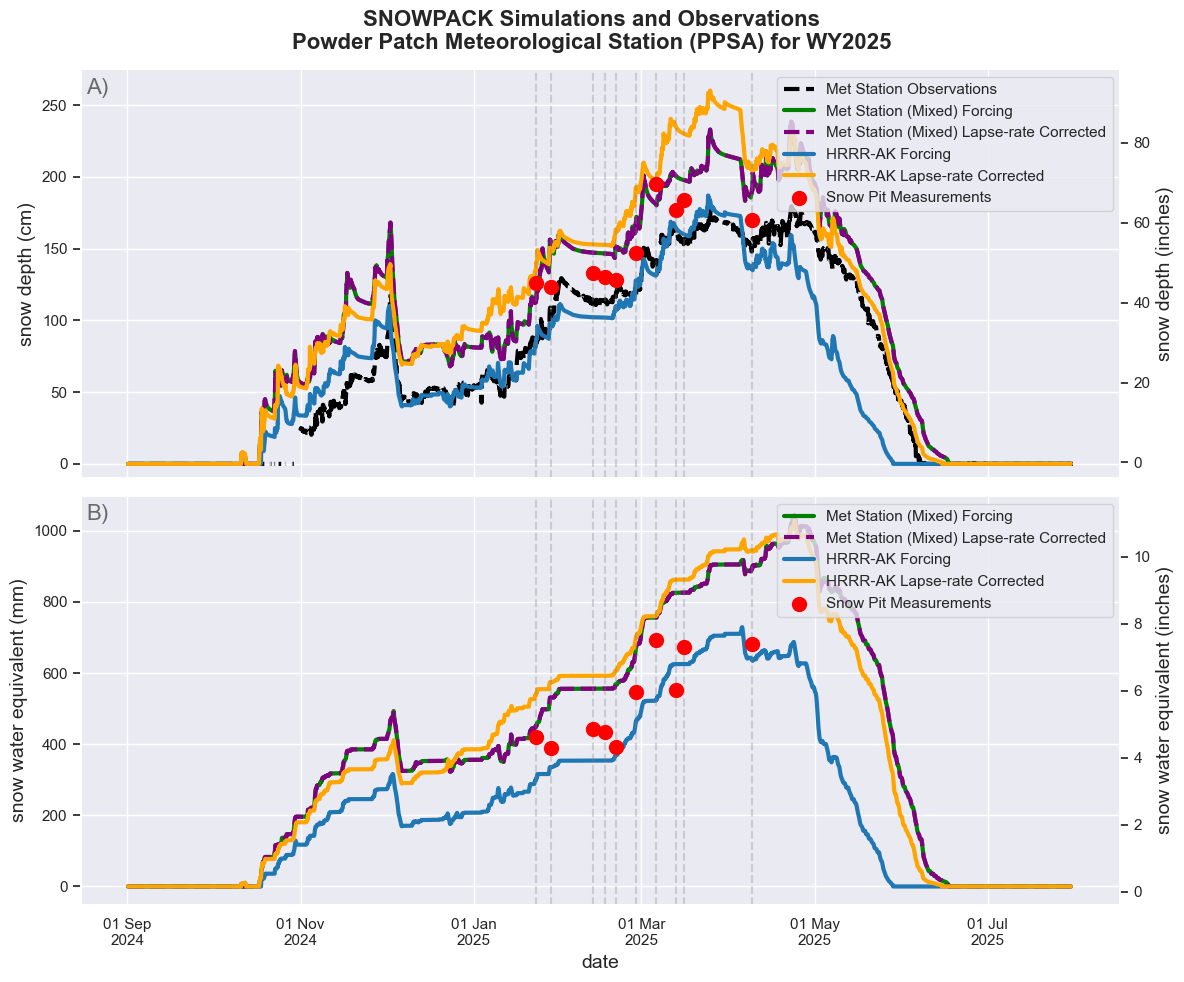

In [17]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ============================================================
# Snow Depth Plot
# ============================================================

# Plot observations and model simulations for snow depth
ds_obs.hs.plot(ax=ax1, label='Met Station Observations', linewidth=3, linestyle='--', color='black')
ds_snowpack_met_hrrrak.HS_mod.plot(ax=ax1, label='Met Station (Mixed) Forcing', linewidth=3, color='green')
ds_snowpack_met_hrrrak_lapserate.HS_mod.plot(ax=ax1, label='Met Station (Mixed) Lapse-rate Corrected', linewidth=3, color='purple', linestyle='--')

ds_snowpack_hrrrak.HS_mod.plot(ax=ax1, label='HRRR-AK Forcing', linewidth=3, color='tab:blue')
ds_snowpack_hrrrak_lapserate.HS_mod.plot(ax=ax1, label='HRRR-AK Lapse-rate Corrected', linewidth=3, color='orange')

# Add vertical lines for the dates in df_field_measurements
for date in df_field_measurements.index:
    ax1.axvline(x=date, color='grey', linestyle='--', alpha=0.3)
    
    # Add a large dot for the snow depth at that date 
    ax1.scatter(date, df_field_measurements.loc[date, 'snow_depth_cm'], color='red', s=100, zorder=5,
                label='Snow Pit Measurements' if date == df_field_measurements.index[0] else "")

# Set titles and labels
fig.suptitle('SNOWPACK Simulations and Observations\nPowder Patch Meteorological Station (PPSA) for WY2025', fontweight='bold', fontsize=16)
# ax1.set_title('Snow Depth', fontsize=14)

ax1.set_ylabel('snow depth (cm)', fontsize=14)
ax1.set_ylim([-10, 275])

# Add a second y-axis for inches
ax1_twin = ax1.twinx()
ax1_twin.set_ylabel('snow depth (inches)', fontsize=14)
ax1_twin.set_ylim([-10/2.54, 250/2.54])
ax1_twin.grid(False)  # Turn off the second grid

# Set legend for snow depth plot
ax1.legend(loc='upper right')

# ============================================================
# SWE Plot
# ============================================================

# Plot model simulations for SWE
ds_snowpack_met_hrrrak.SWE.plot(ax=ax2, label='Met Station (Mixed) Forcing', linewidth=3, color='green')
ds_snowpack_met_hrrrak_lapserate.SWE.plot(ax=ax2, label='Met Station (Mixed) Lapse-rate Corrected', linewidth=3, color='purple', linestyle='--')

ds_snowpack_hrrrak.SWE.plot(ax=ax2, label='HRRR-AK Forcing', linewidth=3, color='tab:blue')
ds_snowpack_hrrrak_lapserate.SWE.plot(ax=ax2, label='HRRR-AK Lapse-rate Corrected', linewidth=3, color='orange')

# Add vertical lines for the dates in df_field_measurements
for date in df_field_measurements.index:
    ax2.axvline(x=date, color='grey', linestyle='--', alpha=0.3)

# Add a large dot for the SWE at that date
ax2.scatter(df_field_measurements.index, df_field_measurements['swe_mm'], color='red', s=100, zorder=5,
            label='Snow Pit Measurements')

# Set titles and labels
ax2.set_ylabel('snow water equivalent (mm)', fontsize=14)

# Add a second y-axis for inches
ax2_twin = ax2.twinx()
ax2_twin.set_ylabel('snow water equivalent (inches)', fontsize=14)
ax2_twin.set_ylim([-10*0.0393701, 300*0.0393701])
ax2_twin.grid(False)  # Turn off the second grid

# Set legend for SWE plot
ax2.legend(loc='upper right')

# Set x-axis label
ax2.set_xlabel('date', fontsize=14)
ax1.set_xlabel('')  # Remove x-axis label from the first plot

# Format x-axis dates as "01 Jan 2025"
import matplotlib.dates as mdates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%Y'))
# fig.autofmt_xdate(rotation=45, ha='right')


# add an A) and B) 
ax1.text(0.005, 0.98, 'A)', transform=ax1.transAxes, fontsize=16, color='dimgrey', va='top')
ax2.text(0.005, 0.98, 'B)', transform=ax2.transAxes, fontsize=16, color='dimgrey', va='top')

# Show the plot
plt.tight_layout()
plt.show()


## Calculate Statistics 

In [18]:
# the model have a "timestamp" instead of "time" dimension, so rename that for consistency
# xarray rename returns a new dataset unless inplace=False, so assign the result.
ds_snowpack_hrrrak = ds_snowpack_hrrrak.rename({"timestamp": "time"})
ds_snowpack_met_hrrrak = ds_snowpack_met_hrrrak.rename({"timestamp": "time"})
ds_snowpack_hrrrak_lapserate = ds_snowpack_hrrrak_lapserate.rename({"timestamp": "time"})

Need to edit the code below to include the lapse-rate for met...

In [19]:
# ============================================================
# Snow pit vs model comparison table for Figure 4
# PPSA WY2025
# ============================================================

def extract_model_at_pit_dates(model_da, pit_dates):
    """
    Extract model values at snow pit dates using nearest timestamp.
    """
    return (
        model_da
        .sel(time=pit_dates, method="nearest")
        .to_pandas()
    )


# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

df_pit_compare = df_field_measurements.copy()

pit_dates = df_pit_compare.index

# Snow depth model values
df_pit_compare["HS_HRRR_cm"] = extract_model_at_pit_dates(
    ds_snowpack_hrrrak.HS_mod,
    pit_dates
).values

df_pit_compare["HS_Mixed_cm"] = extract_model_at_pit_dates(
    ds_snowpack_met_hrrrak.HS_mod,
    pit_dates
).values

# SWE model values
df_pit_compare["SWE_HRRR_mm"] = extract_model_at_pit_dates(
    ds_snowpack_hrrrak.SWE,
    pit_dates
).values

df_pit_compare["SWE_Mixed_mm"] = extract_model_at_pit_dates(
    ds_snowpack_met_hrrrak.SWE,
    pit_dates
).values


# ------------------------------------------------------------
# Calculate differences: model - observed
# Positive = model overestimates observation
# Negative = model underestimates observation
# ------------------------------------------------------------

df_pit_compare["HS_HRRR_error_cm"] = (
    df_pit_compare["HS_HRRR_cm"] -
    df_pit_compare["snow_depth_cm"]
)

df_pit_compare["HS_Mixed_error_cm"] = (
    df_pit_compare["HS_Mixed_cm"] -
    df_pit_compare["snow_depth_cm"]
)

df_pit_compare["SWE_HRRR_error_mm"] = (
    df_pit_compare["SWE_HRRR_mm"] -
    df_pit_compare["swe_mm"]
)

df_pit_compare["SWE_Mixed_error_mm"] = (
    df_pit_compare["SWE_Mixed_mm"] -
    df_pit_compare["swe_mm"]
)


# ------------------------------------------------------------
# Optional: create compact table of all pit comparisons
# ------------------------------------------------------------

pit_comparison_table = df_pit_compare[
    [
        "snow_depth_cm",
        "HS_HRRR_cm",
        "HS_HRRR_error_cm",
        "HS_Mixed_cm",
        "HS_Mixed_error_cm",
        "swe_mm",
        "SWE_HRRR_mm",
        "SWE_HRRR_error_mm",
        "SWE_Mixed_mm",
        "SWE_Mixed_error_mm",
    ]
].copy()

pit_comparison_table = pit_comparison_table.round(1)

print("\n")
print("========================================================")
print("SNOW PIT VS MODEL COMPARISON")
print("Positive error = model greater than observed")
print("Negative error = model less than observed")
print("========================================================")
print("\n")

print(pit_comparison_table.to_string())


# ------------------------------------------------------------
# Summary statistics across all snow pits
# ------------------------------------------------------------

error_cols = [
    "HS_HRRR_error_cm",
    "HS_Mixed_error_cm",
    "SWE_HRRR_error_mm",
    "SWE_Mixed_error_mm",
]

summary_stats = (
    df_pit_compare[error_cols]
    .agg(["mean", "min", "max"])
    .T
    .rename(
        columns={
            "mean": "Mean Error",
            "min": "Minimum Error",
            "max": "Maximum Error",
        }
    )
)

summary_stats = summary_stats.round(1)

print("\n")
print("========================================================")
print("SUMMARY OF MODEL ERRORS ACROSS ALL SNOW PITS")
print("Positive error = model greater than observed")
print("Negative error = model less than observed")
print("========================================================")
print("\n")

print(summary_stats.to_string())


# ------------------------------------------------------------
# Optional: also calculate mean absolute error for snow pits
# ------------------------------------------------------------

mae_stats = (
    df_pit_compare[error_cols]
    .abs()
    .mean()
    .rename("Mean Absolute Error")
    .to_frame()
)

mae_stats = mae_stats.round(1)

print("\n")
print("========================================================")
print("MEAN ABSOLUTE ERROR ACROSS ALL SNOW PITS")
print("========================================================")
print("\n")

print(mae_stats.to_string())


# ------------------------------------------------------------
# Optional: save outputs
# ------------------------------------------------------------

# pit_comparison_table.to_csv(
#     "ppsa_snow_pit_model_comparison_all_pits.csv"
# )

# summary_stats.to_csv(
#     "ppsa_snow_pit_model_error_summary.csv"
# )

# mae_stats.to_csv(
#     "ppsa_snow_pit_model_mae_summary.csv"
# )



SNOW PIT VS MODEL COMPARISON
Positive error = model greater than observed
Negative error = model less than observed


            snow_depth_cm  HS_HRRR_cm  HS_HRRR_error_cm  HS_Mixed_cm  HS_Mixed_error_cm  swe_mm  SWE_HRRR_mm  SWE_HRRR_error_mm  SWE_Mixed_mm  SWE_Mixed_error_mm
2025-01-23            126        87.8             -38.2        115.9              -10.1   420.8        305.0             -115.8         452.2                31.4
2025-01-28            123        97.3             -25.7        154.1               31.1   389.8        335.6              -54.2         531.2               141.3
2025-02-12            133       102.2             -30.8        147.2               14.2   444.0        353.9              -90.1         556.0               112.0
2025-02-16            130       102.0             -28.0        146.7               16.7   434.0        354.0              -80.0         556.3               122.3
2025-02-20            128       109.2             -18.8        150.8  